In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from retail_data import generate_retail_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [2]:
#load retail data set

df = generate_retail_dataset(n_samples=2000, random_state=RANDOM_STATE)
print(f'Shape: {df.shape}')
df.head()
     

df.info()
df.describe()
     

Shape: (2000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             2000 non-null   int64  
 1   Age                    2000 non-null   int64  
 2   Annual_Income          2000 non-null   int64  
 3   Spending_Score         2000 non-null   int64  
 4   Region                 2000 non-null   str    
 5   Product_Category       2000 non-null   str    
 6   Purchase_Channel       2000 non-null   str    
 7   Num_Purchases          2000 non-null   int64  
 8   Avg_Transaction_Value  2000 non-null   float64
 9   Total_Sales            2000 non-null   float64
 10  Customer_Segment       2000 non-null   str    
dtypes: float64(2), int64(5), str(4)
memory usage: 223.8 KB


,CustomerID,Age,Annual_Income,Spending_Score,Num_Purchases,Avg_Transaction_Value,Total_Sales
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,43.482000,70234.770500,49.456500,15.954000,258.863925,4143.513110
std,577.494589,15.077511,28742.157576,28.505796,3.816172,140.675620,2560.604662
min,1.000000,18.000000,20051.000000,1.000000,3.000000,10.100000,90.830000
25%,500.750000,30.000000,44582.500000,25.000000,13.000000,138.620000,2063.230000
50%,1000.500000,44.000000,69498.500000,49.500000,16.000000,260.185000,3861.625000
75%,1500.250000,57.000000,95127.250000,74.250000,18.000000,382.865000,5940.845000
max,2000.000000,69.000000,119942.000000,99.000000,30.000000,499.860000,13288.110000


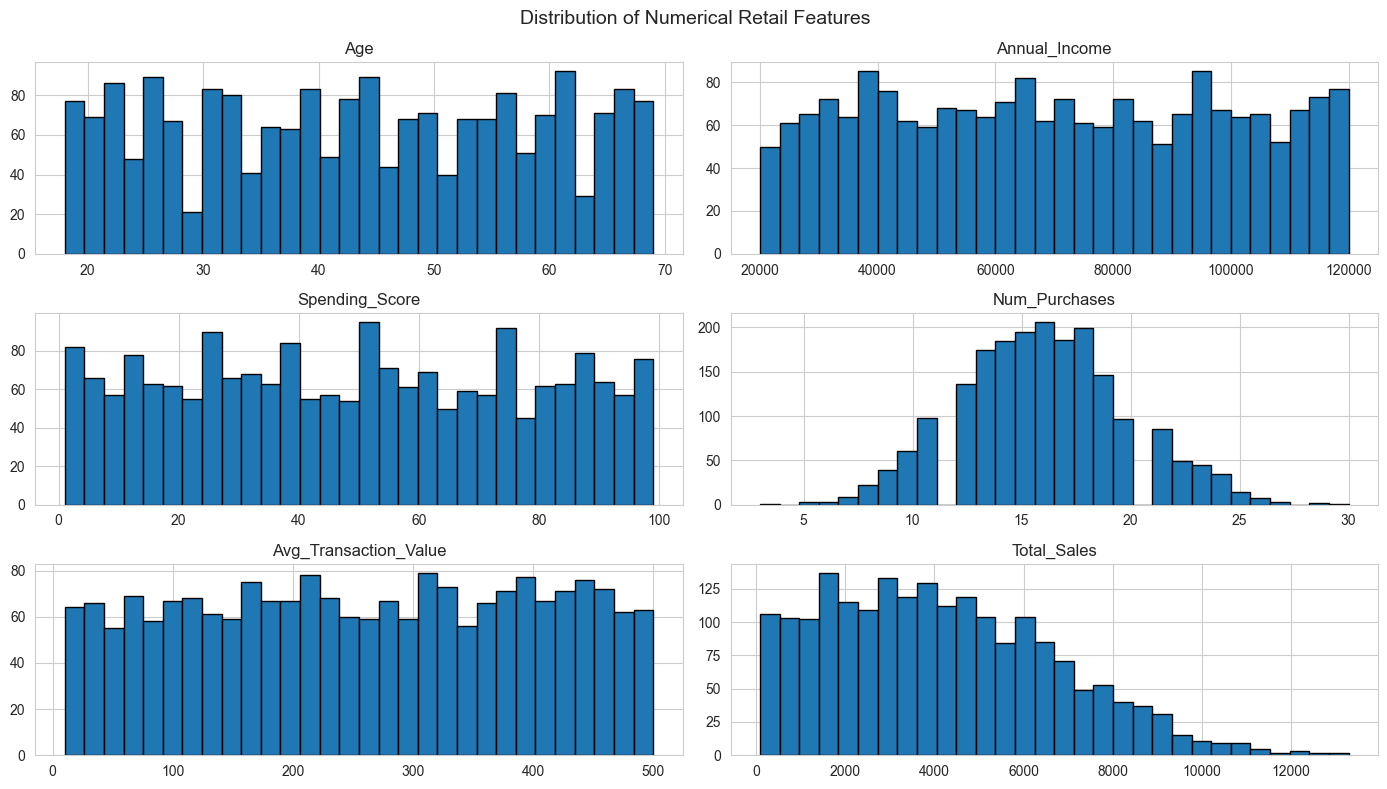

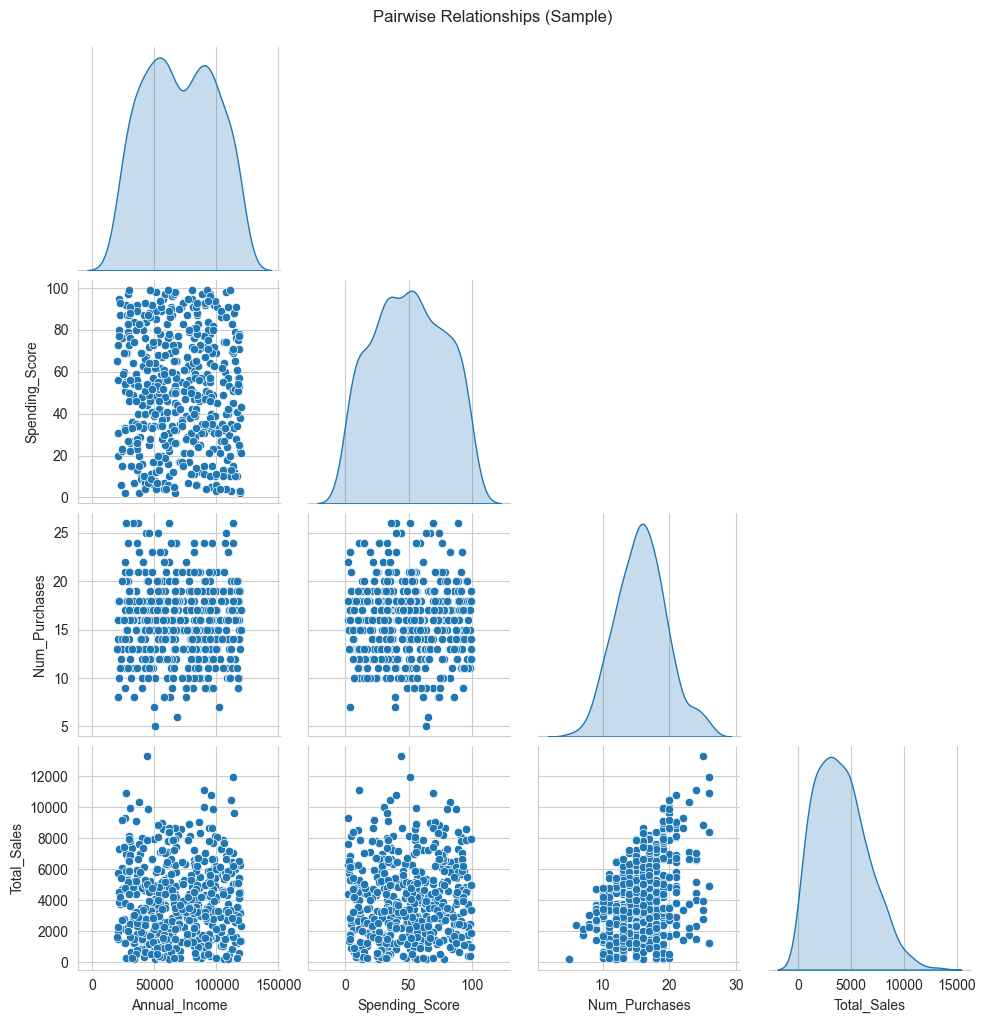

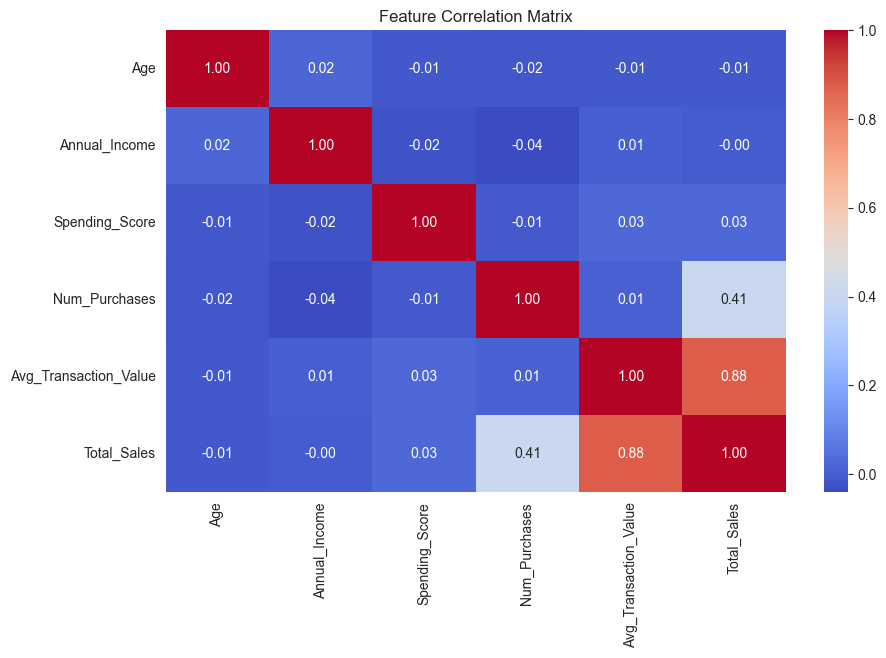

In [3]:
# 2. Exploratory Data Analysis

numerical_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value', 'Total_Sales']
df[numerical_cols].hist(bins=30, figsize=(14, 8), edgecolor='black')
plt.suptitle('Distribution of Numerical Retail Features', fontsize=14)
plt.tight_layout()
plt.show()
     

sns.pairplot(df[['Annual_Income', 'Spending_Score', 'Num_Purchases', 'Total_Sales']].sample(500, random_state=RANDOM_STATE),
             diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships (Sample)', y=1.02)
plt.show()
     

corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [4]:
# 3. Feature Selection & Preprocessing
# K-Means works on numerical features. We select behavioral and demographic variables and scale them.


feature_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Features used: {feature_cols}')
print(f'Scaled shape: {X_scaled.shape}')

Features used: ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']
Scaled shape: (2000, 5)


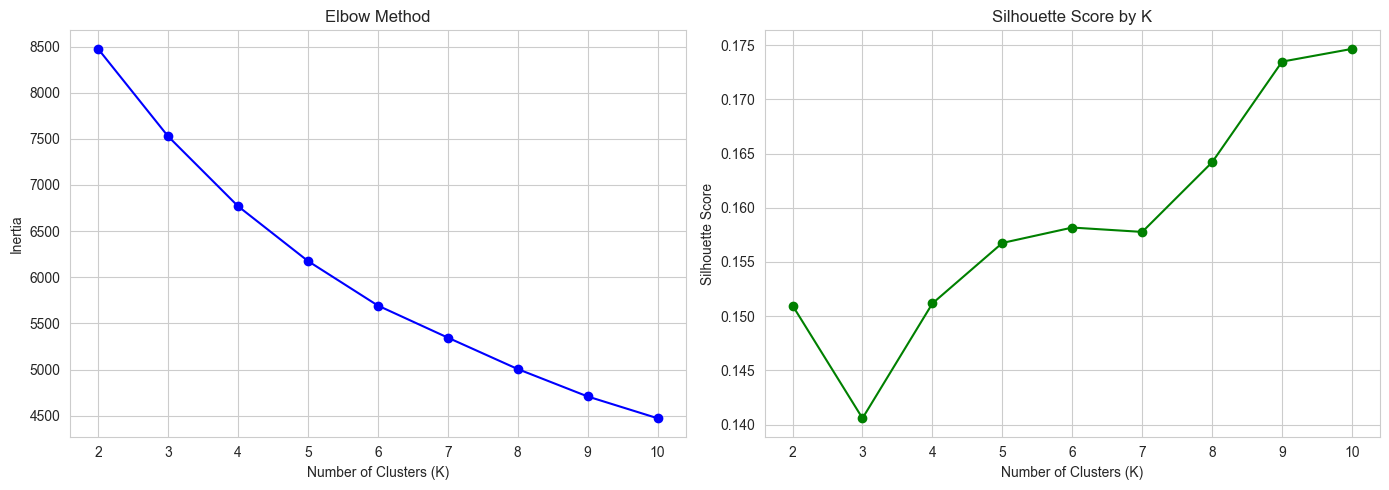

Optimal K (by silhouette): 10


In [5]:
# 4. Find Optimal K (Elbow & Silhouette)

k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouettes, 'go-')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouettes)]
print(f'Optimal K (by silhouette): {optimal_k}')

In [6]:
# 5. Train Final K-Means Model

OPTIMAL_K = optimal_k
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nSilhouette Score: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(f'Davies-Bouldin Index: {davies_bouldin_score(X_scaled, df["Cluster"]):.4f}')
print(f'Calinski-Harabasz Score: {calinski_harabasz_score(X_scaled, df["Cluster"]):.4f}')

Cluster distribution:
Cluster
0    167
1    181
2    229
3    192
4    215
5    187
6    211
7    195
8    219
9    204
Name: count, dtype: int64

Silhouette Score: 0.1747
Davies-Bouldin Index: 1.3175
Calinski-Harabasz Score: 273.3638


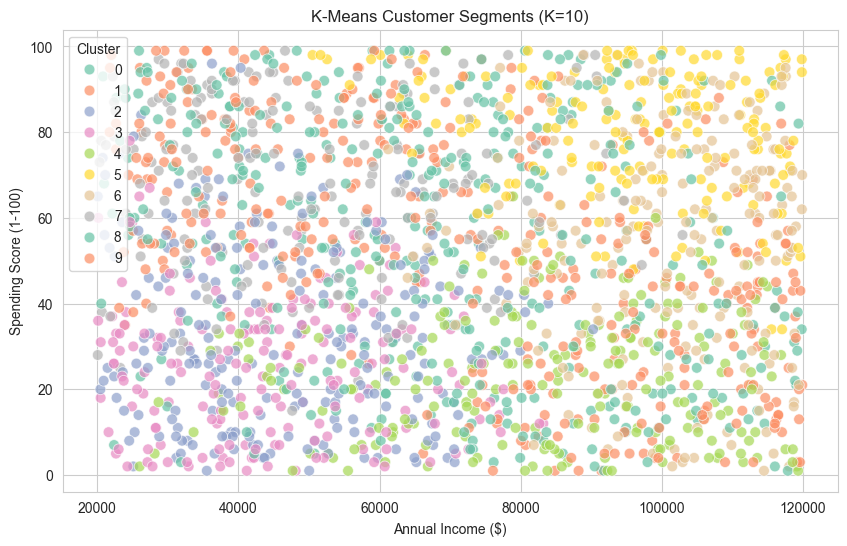

In [12]:
# 6. Visualize Clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income', y='Spending_Score', hue='Cluster', palette='Set2', s=60, alpha=0.7)
plt.title(f'K-Means Customer Segments (K={OPTIMAL_K})')
plt.xlabel('Annual Income ($)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()
     

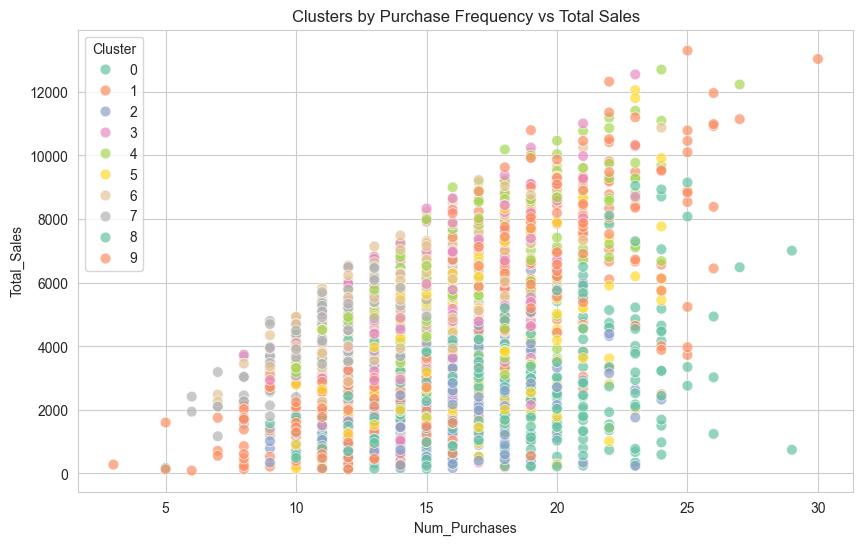

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Num_Purchases', y='Total_Sales', hue='Cluster', palette='Set2', s=60, alpha=0.7)
plt.title('Clusters by Purchase Frequency vs Total Sales')
plt.show()

In [9]:
cluster_profile = df.groupby('Cluster')[feature_cols + ['Total_Sales']].mean().round(2)
cluster_profile
     

,Age,Annual_Income,Spending_Score,Num_Purchases,Avg_Transaction_Value,Total_Sales
Cluster,,,,,,
0,34.04,80789.79,28.04,20.51,154.90,3194.51
1,45.38,97877.18,32.39,12.40,136.25,1636.52
2,56.64,46421.62,33.16,15.89,135.05,2168.58
3,29.10,44382.84,25.76,15.61,322.11,5078.42
4,56.32,83108.39,23.06,16.75,371.50,6279.90
5,58.07,95867.09,79.54,16.87,233.15,3937.95
6,29.32,101088.87,54.50,14.69,377.04,5562.06
7,51.07,50330.32,67.56,12.07,359.54,4309.54
8,29.80,59325.38,75.93,15.15,123.29,1864.18


In [10]:
segment_crosstab = pd.crosstab(df['Cluster'], df['Customer_Segment'], normalize='index').round(3)
print('Cluster vs Actual Customer Segment (proportion):')
segment_crosstab  

Cluster vs Actual Customer Segment (proportion):


Customer_Segment,Budget,Premium,Regular,VIP
Cluster,,,,
0,0.078,0.257,0.647,0.018
1,0.000,0.503,0.442,0.055
2,0.362,0.044,0.594,0.000
3,0.469,0.000,0.531,0.000
4,0.102,0.237,0.660,0.000
5,0.000,0.428,0.000,0.572
6,0.000,0.498,0.175,0.327
7,0.046,0.503,0.426,0.026
8,0.000,0.580,0.283,0.137
